# Import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# Helper Functions

In [3]:
def voigt_profile_single(x, A1, centre1, gamma1, sigma1, offset):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1) + offset)

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def lorentzian_profile(x, gamma):
    return gamma / (np.pi * (x**2 + gamma**2))

def lorentzian_single_model(x, A, center, gamma, offset):
    return A*lorentzian_profile(x- center, gamma) + offset


def lorentzian_model_double(x, A1, center1, gamma1,
                            A2, delta, gamma2, offset):

    return (
        A1 * lorentzian_profile(x - center1, gamma1) +
        A2 * lorentzian_profile(x - (center1 + delta), gamma2) +
        offset
    )

def gaussian_profile(x, sigma):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x**2)/(2*sigma**2))

def gaussian_single_model(x, A, center, sigma, offset):
    return A * gaussian_profile(x - center, sigma) + offset

def gaussian_model_double(x, A1, center1, sigma1,
                          A2, delta, sigma2, offset):

    return (
        A1 * gaussian_profile(x - center1, sigma1) +
        A2 * gaussian_profile(x - (center1 + delta), sigma2) +
        offset
    )




def reduced_chi_squared_calc(model, model_params, xdata, ydata, yerror):
    dof = len(xdata)-len(model_params)
    theoretical = model(xdata,*model_params)
    chi2 = np.sum((theoretical - ydata)**2/(yerror**2))
    rchi2 = chi2/dof
    return chi2, rchi2

def residual_calculator(xdata, ydata, yerr, model, model_params):
    fit = model(xdata, *model_params)
    residual = ydata - fit
    norm_residual = residual/yerr
    return  norm_residual

def wavelength_extraction(x, start_index):
    A = 0.9958
    B = 9096.6280
    return (start_index - 0.242 * x - B) / A




def normalise_spectra(df, cols, wavelengths):
    dx = np.abs(wavelengths[1] - wavelengths[0])
    area_0 = np.sum(df[cols[0]] * dx)

    normalised = []

    for col in cols:
        spec = df[col].to_numpy()
        norm = (spec / np.sum(spec * dx)) * area_0
        normalised.append(norm)

    matrix = np.column_stack(normalised)

    mean_intensity = np.mean(matrix, axis=1)
    error = np.std(matrix, axis=1) / np.sqrt(len(cols))

    return normalised, mean_intensity, error

# Data Sets

In [4]:
# Monochromator

mono_file = "Monodchromator_Data_Initialisation.xlsx"

df = pd.read_excel(mono_file)

indexes = np.arange(0, 250, 1)
wavelengths = wavelength_extraction(indexes, 9830)


I_77_normalised, I_77_mean, I_77_err = normalise_spectra(df, ["77_0", "77_1"], wavelengths)
I_147_normalised, I_147_mean, I_147_err = normalise_spectra(df, ["147_0", "147_1"], wavelengths)
I_217_normalised, I_217_mean, I_217_err = normalise_spectra(df, ["217_0", "217_1"], wavelengths)
I_298_normalised, I_298_mean, I_298_err = normalise_spectra(df, ["298_0", "298_1", "298_2", "298_3", "298_4", "298_5", "298_6", "298_7", "298_8", "298_9"], wavelengths)

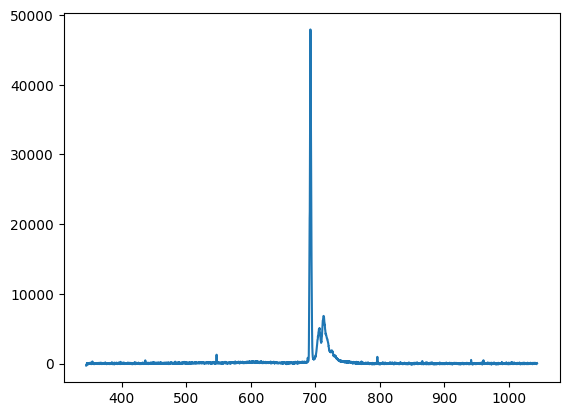

In [5]:
# Ocean Optics

ocean_file = "Ocean_Opt_Data.xlsx"

df_ocean = pd.read_excel(ocean_file)

x_ocean_77 = df_ocean["W_77"].to_numpy()
x_ocean_147 = df_ocean["W_130"].to_numpy()
x_ocean_217 = df_ocean["W_217"].to_numpy()
x_ocean_298 = df_ocean["W_298"].to_numpy()

y_ocean_77 = df_ocean["I_77"].to_numpy()
y_ocean_147 = df_ocean["I_130"].to_numpy()
y_ocean_217 = df_ocean["I_217"].to_numpy()
y_ocean_298 = df_ocean["I_298"].to_numpy()

plt.figure(1)
plt.plot(x_ocean_77, y_ocean_77)

plt.show()

----- Mono -----


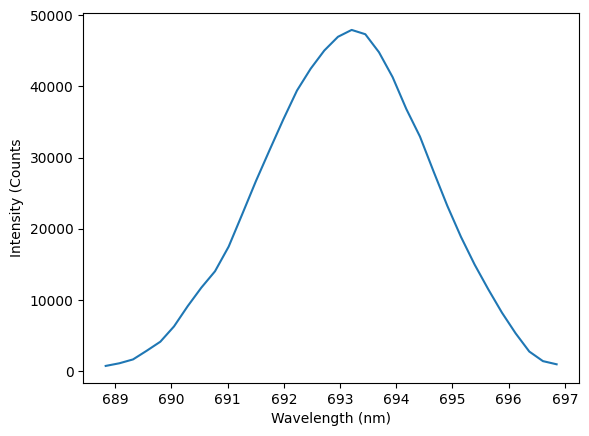

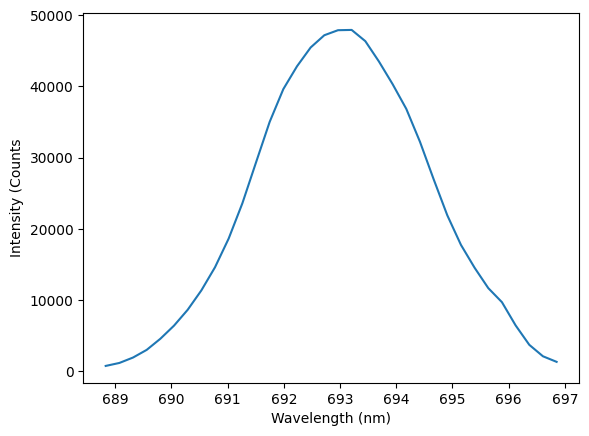

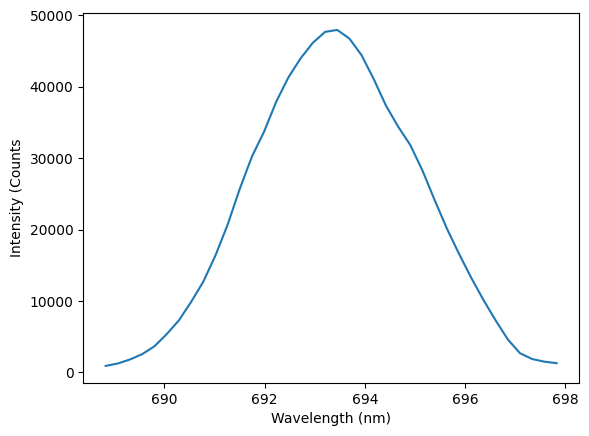

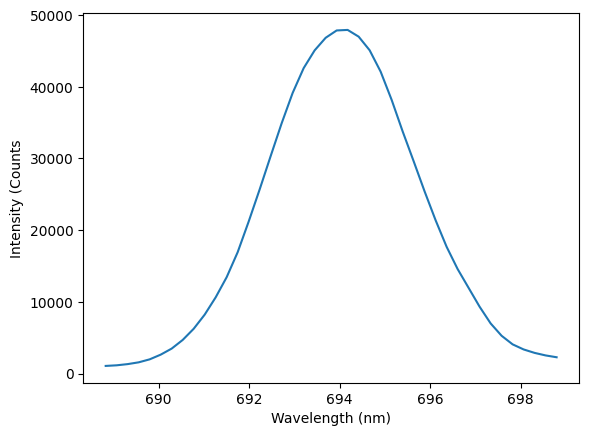

----- Ocean -----


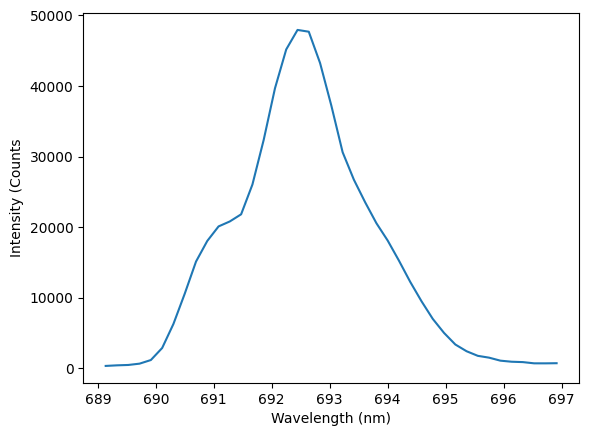

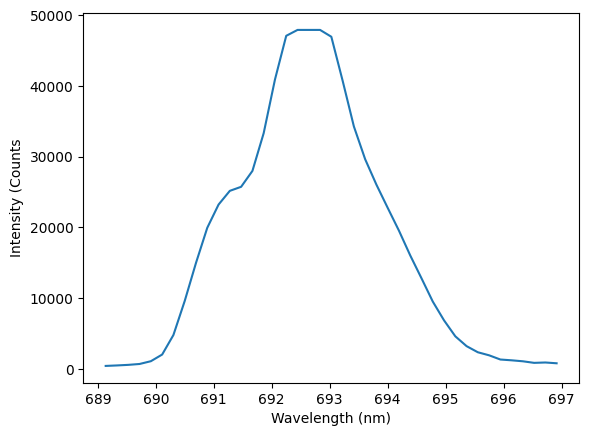

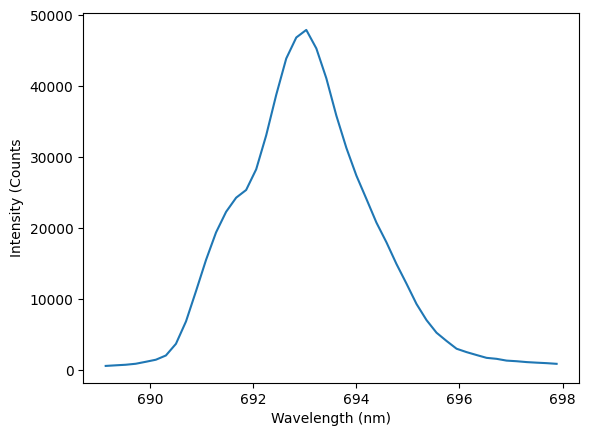

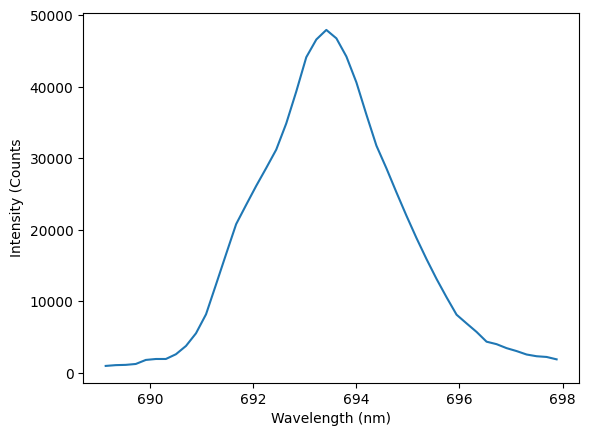

In [6]:
# Mask Mono and Ocean optics

mask_min_ocean = 689.1
mask_max_ocean = 697

mask_min_mono = 688.7
mask_max_mono = 697

temps = [77,147,217,298]

mask_min_ocean = [689.1, 689.1, 689.1, 689.1]
mask_max_ocean = [697, 697, 698, 698]
mask_min_mono = [688.7, 688.7, 688.7, 688.7]
mask_max_mono = [697, 697, 698, 699]

x_ocean = [x_ocean_77, x_ocean_147, x_ocean_217, x_ocean_298]
y_ocean = [y_ocean_77, y_ocean_147, y_ocean_217, y_ocean_298]

I_mono = [I_77_mean, I_147_mean, I_217_mean, I_298_mean]
I_mono_err = [I_77_err, I_147_err, I_217_err, I_298_err]

x_ocean_masked = []
y_ocean_masked = []
y_mono_masked = []
y_mono_err_masked = []
wavelengths_masked = []

for xo, yo, I, I_err, min_ocean, max_ocean, min_mono, max_mono in zip(
        x_ocean, y_ocean, I_mono, I_mono_err,
        mask_min_ocean, mask_max_ocean, mask_min_mono, mask_max_mono):

    mask_ocean = (xo >= min_ocean) & (xo <= max_ocean)
    mask_mono  = (wavelengths >= min_mono) & (wavelengths <= max_mono)

    x_ocean_mask = xo[mask_ocean]
    y_ocean_mask = yo[mask_ocean]
    y_mono_mask = I[mask_mono]
    y_mono_err_mask = I_err[mask_mono]

    normalisation_scalefactor_mono = (np.max(y_ocean_77) / np.max(y_mono_mask))
    normalisation_scalefactor_ocean = (np.max(y_ocean_77) / np.max(y_ocean_mask))

    y_ocean_mask = y_ocean_mask*normalisation_scalefactor_ocean

    x_ocean_masked.append(x_ocean_mask)
    y_ocean_masked.append(y_ocean_mask)

    y_mono_mask = y_mono_mask * normalisation_scalefactor_mono
    y_mono_err_mask = y_mono_err_mask * normalisation_scalefactor_mono

    y_mono_masked.append(y_mono_mask)
    y_mono_err_masked.append(y_mono_err_mask)
    wavelengths_masked.append(wavelengths[mask_mono])

print(f"----- Mono -----")
for i in range(len(y_mono_masked)):
    plt.figure(1)
    plt.plot(wavelengths_masked[i], y_mono_masked[i])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts")
    plt.show()

print(f"----- Ocean -----")

for i in range(len(y_ocean_masked)):
    plt.figure(1)
    plt.plot(x_ocean_masked[i], y_ocean_masked[i])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts")
    plt.show()

# Fitting Mono

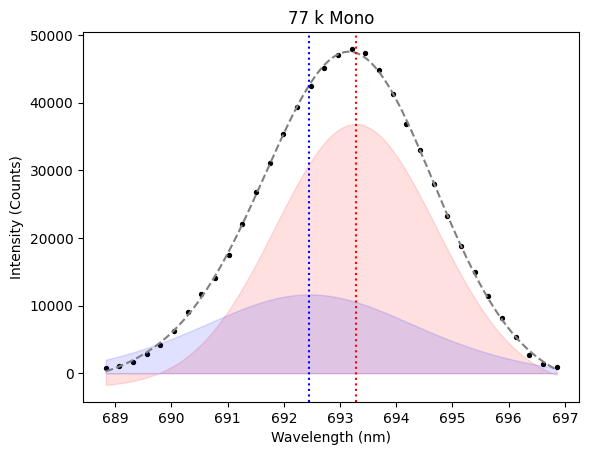

In [7]:
####
# 77
####

A1_guess_mono = np.max(y_mono_masked[0])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_77 = wavelengths_masked[0][np.argmax(y_mono_masked[0])]
offset_guess_mono_77 = np.min(y_mono_masked[0])

p0_mono_77 = [A1_guess_mono, R1_guess_mono_77, 2, 2,
              A2_guess_mono, -1.4, 2, 2, offset_guess_mono_77]

bounds_mono_77 = [
    [0.01*A1_guess_mono, R1_guess_mono_77 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_77 + 5, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_77, cov_mono_77 = curve_fit(voigt_model_double,
                                     wavelengths_masked[0],
                                     y_mono_masked[0],
                                     p0 = p0_mono_77,
                                     bounds = bounds_mono_77,
                                     maxfev = 10000)

x_fit_77 = np.linspace(wavelengths_masked[0][-1], wavelengths_masked[0][0], 10000)

pop_R1_mono_77 = [pop_mono_77[0], pop_mono_77[1], pop_mono_77[2], pop_mono_77[3], pop_mono_77[-1]/2]
cov_R1_mono_77 = [cov_mono_77[0][0], cov_mono_77[1][1], cov_mono_77[2][2], cov_mono_77[3][3], cov_mono_77[-1][-1]/2]
R1_mono_77 = voigt_profile_single(x_fit_77, *pop_R1_mono_77)

pop_R2_mono_77 = [pop_mono_77[4], pop_mono_77[5] + pop_mono_77[1], pop_mono_77[6], pop_mono_77[7], pop_mono_77[-1]/2]
cov_R2_mono_77 = [cov_mono_77[4][4], cov_mono_77[5][5] + cov_mono_77[1][1], cov_mono_77[6][6], cov_mono_77[7][7], cov_mono_77[-1][-1]/2]
R2_mono_77 = voigt_profile_single(x_fit_77, *pop_R2_mono_77)

plt.figure(1)
plt.scatter(wavelengths_masked[0], y_mono_masked[0], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_77, voigt_model_double(x_fit_77, *pop_mono_77), color = "grey", linestyle = "--")

plt.fill_between(x_fit_77, R1_mono_77, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_77, R2_mono_77, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_77[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_77[1], color = "blue", linestyle = ":")

plt.title("77 k Mono")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

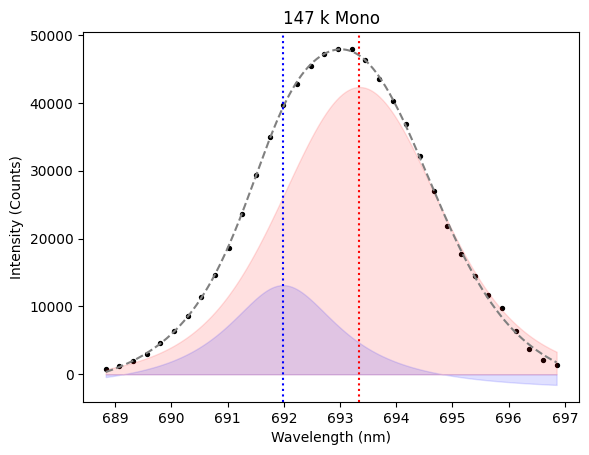

In [9]:
####
# 147
####

A1_guess_mono = np.max(y_mono_masked[1])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_147 = wavelengths_masked[1][np.argmax(y_mono_masked[1])]
offset_guess_mono_147 = np.min(y_mono_masked[1])

p0_mono_147 = [A1_guess_mono, R1_guess_mono_147, 2, 2,
              A2_guess_mono, -1.4, 2, 2, offset_guess_mono_147]

bounds_mono_147 = [
    [0.01*A1_guess_mono, R1_guess_mono_147 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_147 + 5, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_147, cov_mono_147 = curve_fit(voigt_model_double,
                                     wavelengths_masked[1],
                                     y_mono_masked[1],
                                     p0 = p0_mono_147,
                                     bounds = bounds_mono_147,
                                     maxfev = 10000)

x_fit_147 = np.linspace(wavelengths_masked[1][-1], wavelengths_masked[1][0], 10000)

pop_R1_mono_147 = [pop_mono_147[0], pop_mono_147[1], pop_mono_147[2], pop_mono_147[3], pop_mono_147[-1]/2]
cov_R1_mono_147 = [cov_mono_147[0][0], cov_mono_147[1][1], cov_mono_147[2][2], cov_mono_147[3][3], cov_mono_147[-1][-1]/2]
R1_mono_147 = voigt_profile_single(x_fit_147, *pop_R1_mono_147)

pop_R2_mono_147 = [pop_mono_147[4], pop_mono_147[5] + pop_mono_147[1], pop_mono_147[6], pop_mono_147[7], pop_mono_147[-1]/2]
cov_R2_mono_147 = [cov_mono_147[4][4], cov_mono_147[5][5] + cov_mono_147[1][1], cov_mono_147[6][6], cov_mono_147[7][7], cov_mono_147[-1][-1]/2]
R2_mono_147 = voigt_profile_single(x_fit_147, *pop_R2_mono_147)

plt.figure(1)
plt.scatter(wavelengths_masked[1], y_mono_masked[1], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_147, voigt_model_double(x_fit_147, *pop_mono_147), color = "grey", linestyle = "--")

plt.fill_between(x_fit_147, R1_mono_147, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_147, R2_mono_147, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_147[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_147[1], color = "blue", linestyle = ":")

plt.title("147 k Mono")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

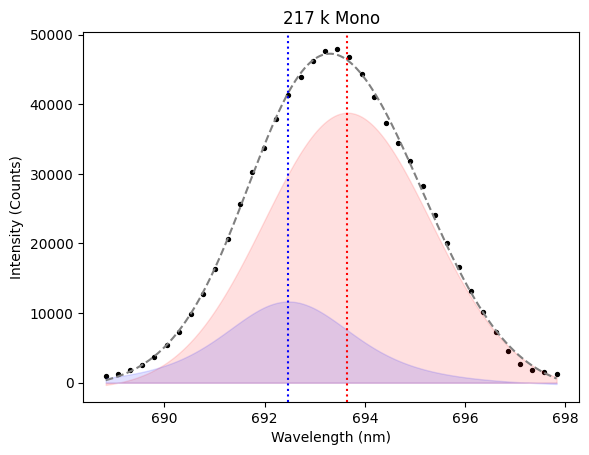

In [10]:
####
# 217
####

A1_guess_mono = np.max(y_mono_masked[2])/2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_217 = wavelengths_masked[2][np.argmax(y_mono_masked[2])]
offset_guess_mono_217 = np.min(y_mono_masked[2])

p0_mono_217 = [A1_guess_mono, R1_guess_mono_217, 2, 2,
              A2_guess_mono, -1.4, 2, 2, offset_guess_mono_217]

bounds_mono_217 = [
    [0.01*A1_guess_mono, R1_guess_mono_217 - 5, 0, 0,
     0.01*A2_guess_mono, -3, 0, 0, -np.inf], #lower
    [10*A1_guess_mono, R1_guess_mono_217 + 0.2, np.inf, np.inf,
     10*A2_guess_mono, -0.5, np.inf, np.inf, np.inf] #upper
]

pop_mono_217, cov_mono_217 = curve_fit(voigt_model_double,
                                     wavelengths_masked[2],
                                     y_mono_masked[2],
                                     p0 = p0_mono_217,
                                     bounds = bounds_mono_217,
                                     maxfev = 10000)

x_fit_217 = np.linspace(wavelengths_masked[2][-1], wavelengths_masked[2][0], 10000)

pop_R1_mono_217 = [pop_mono_217[0], pop_mono_217[1], pop_mono_217[2], pop_mono_217[3], pop_mono_217[-1]/2]
cov_R1_mono_217 = [cov_mono_217[0][0], cov_mono_217[1][1], cov_mono_217[2][2], cov_mono_217[3][3], cov_mono_217[-1][-1]/2]
R1_mono_217 = voigt_profile_single(x_fit_217, *pop_R1_mono_217)

pop_R2_mono_217 = [pop_mono_217[4], pop_mono_217[5] + pop_mono_217[1], pop_mono_217[6], pop_mono_217[7], pop_mono_217[-1]/2]
cov_R2_mono_217 = [cov_mono_217[4][4], cov_mono_217[5][5] + cov_mono_217[1][1], cov_mono_217[6][6], cov_mono_217[7][7], cov_mono_217[-1][-1]/2]
R2_mono_217 = voigt_profile_single(x_fit_217, *pop_R2_mono_217)

plt.figure(1)
plt.scatter(wavelengths_masked[2], y_mono_masked[2], marker = 'o', color = "black", s = 8)
plt.plot(x_fit_217, voigt_model_double(x_fit_217, *pop_mono_217), color = "grey", linestyle = "--")

plt.fill_between(x_fit_217, R1_mono_217, 0 , color = "red", alpha = 0.12)
plt.fill_between(x_fit_217, R2_mono_217, 0 , color = "blue", alpha = 0.12)

plt.axvline(pop_R1_mono_217[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_mono_217[1], color = "blue", linestyle = ":")

plt.title("217 k Mono")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

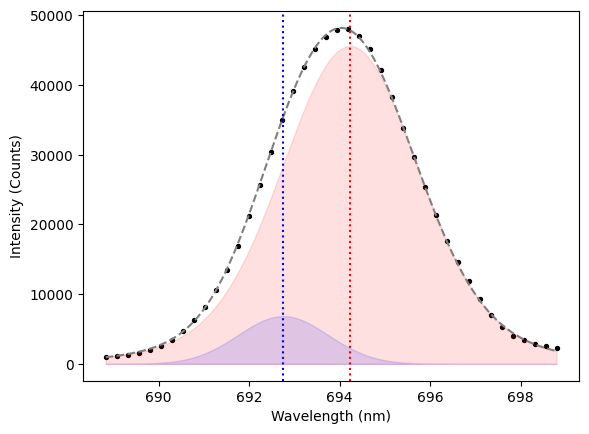

In [11]:
####
# 298
####

A1_guess_mono = np.max(y_mono_masked[3]) / 2
A2_guess_mono = 0.6 * A1_guess_mono
R1_guess_mono_298 = wavelengths_masked[3][np.argmax(y_mono_masked[3])]
offset_guess_mono_298 = np.min(y_mono_masked[3])

p0_mono_298 = [A1_guess_mono, R1_guess_mono_298, 2, 2,
               A2_guess_mono, -1.4, 2, 2, offset_guess_mono_298]

bounds_mono_298 = [
    [0.01 * A1_guess_mono, R1_guess_mono_298 - 5, 0, 0,
     0.01 * A2_guess_mono, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_mono, R1_guess_mono_298 + 5, np.inf, np.inf,
     10 * A2_guess_mono, -0.5, np.inf, np.inf, np.inf]  #upper
]

pop_mono_298, cov_mono_298 = curve_fit(voigt_model_double,
                                       wavelengths_masked[3],
                                       y_mono_masked[3],
                                       p0=p0_mono_298,
                                       bounds=bounds_mono_298,
                                       maxfev=10000)

x_fit_298 = np.linspace(wavelengths_masked[3][-1], wavelengths_masked[3][0], 10000)

pop_R1_mono_298 = [pop_mono_298[0], pop_mono_298[1], pop_mono_298[2], pop_mono_298[3], pop_mono_298[-1]]
cov_R1_mono_298 = [cov_mono_298[0][0], cov_mono_298[1][1], cov_mono_298[2][2], cov_mono_298[3][3], cov_mono_298[-1][-1]]
R1_mono_298 = voigt_profile_single(x_fit_298, *pop_R1_mono_298)

pop_R2_mono_298 = [pop_mono_298[4], pop_mono_298[5] + pop_mono_298[1], pop_mono_298[6], pop_mono_298[7], 0]
cov_R2_mono_298 = [cov_mono_298[4][4], cov_mono_298[5][5] + cov_mono_298[1][1], cov_mono_298[6][6], cov_mono_298[7][7], 0]
R2_mono_298 = voigt_profile_single(x_fit_298, *pop_R2_mono_298)

plt.figure(1)
plt.scatter(wavelengths_masked[3], y_mono_masked[3], marker='o', color="black", s=8)
plt.plot(x_fit_298, voigt_model_double(x_fit_298, *pop_mono_298), color="grey", linestyle="--")

plt.fill_between(x_fit_298, R1_mono_298, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_298, R2_mono_298, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_mono_298[1], color="red", linestyle=":")
plt.axvline(pop_R2_mono_298[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

# Fitting Ocean

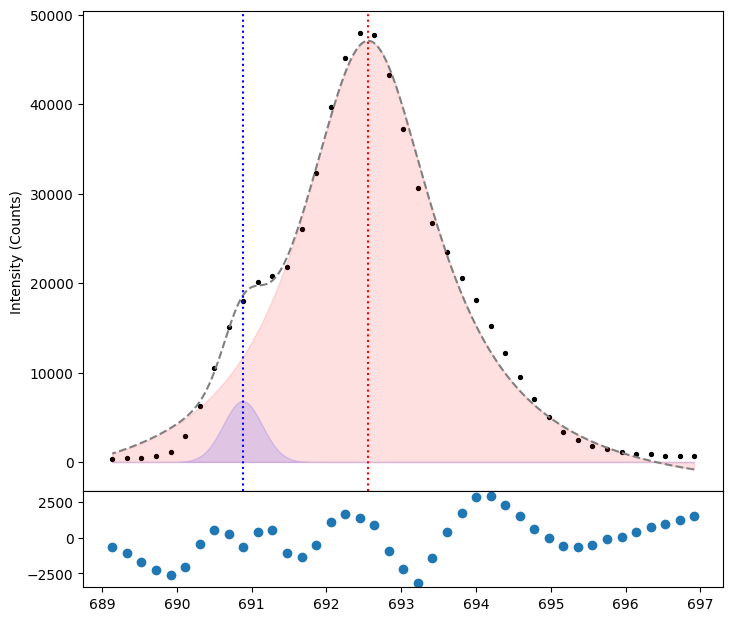

In [91]:
####
# 77
####

A1_guess_ocean = np.max(y_ocean_masked[0]) / 2
A2_guess_ocean = 0.6 * A1_guess_ocean
R1_guess_ocean_77 = wavelengths_masked[0][np.argmax(y_ocean_masked[0])]
offset_guess_ocean_77 = np.min(y_ocean_masked[0])

p0_ocean_77 = [A1_guess_ocean, R1_guess_ocean_77, 0.3, 0.3,
               A2_guess_ocean, -2, 0.3, 0.3, offset_guess_ocean_77]

bounds_ocean_77 = [
    [0.01 * A1_guess_ocean, R1_guess_ocean_77 - 5, 0, 0,
     0.01 * A2_guess_ocean, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_ocean, R1_guess_ocean_77 + 5, np.inf, np.inf,
     10 * A2_guess_ocean, -1, np.inf, np.inf, np.inf]  #upper
]

pop_ocean_77, cov_ocean_77 = curve_fit(voigt_model_double,
                                       x_ocean_masked[0],
                                       y_ocean_masked[0],
                                       p0=p0_ocean_77,
                                       bounds=bounds_ocean_77,
                                       maxfev=10000)

x_fit_77 = np.linspace(x_ocean_masked[0][-1], x_ocean_masked[0][0], 10000)

pop_R1_ocean_77 = [pop_ocean_77[0], pop_ocean_77[1], pop_ocean_77[2], pop_ocean_77[3], pop_ocean_77[-1]]
R1_ocean_77 = voigt_profile_single(x_fit_77, *pop_R1_ocean_77)

pop_R2_ocean_77 = [pop_ocean_77[4], pop_ocean_77[5] + pop_ocean_77[1], pop_ocean_77[6], pop_ocean_77[7], 0]
R2_ocean_77 = voigt_profile_single(x_fit_77, *pop_R2_ocean_77)

cov_R1_ocean_77 = [cov_ocean_77[0][0], cov_ocean_77[1][1], cov_ocean_77[2][2], cov_ocean_77[3][3], cov_ocean_77[-1][-1]]
cov_R2_ocean_77 = [cov_ocean_77[4][4], cov_ocean_77[5][5] + cov_ocean_77[1][1], cov_ocean_77[6][6], cov_ocean_77[7][7], 0]

fig = plt.figure(1)
fig.add_axes([0,0,1,1])
plt.scatter(x_ocean_masked[0], y_ocean_masked[0], marker='o', color="black", s=8)
plt.plot(x_fit_77, voigt_model_double(x_fit_77, *pop_ocean_77), color="grey", linestyle="--")

plt.fill_between(x_fit_77, R1_ocean_77, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_77, R2_ocean_77, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_ocean_77[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_77[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")

fig.add_axes([0,-0.2,1,0.2])
plt.scatter(x_ocean_masked[0],(y_ocean_masked[0]-voigt_model_double(x_ocean_masked[0], *pop_ocean_77)))
plt.show()

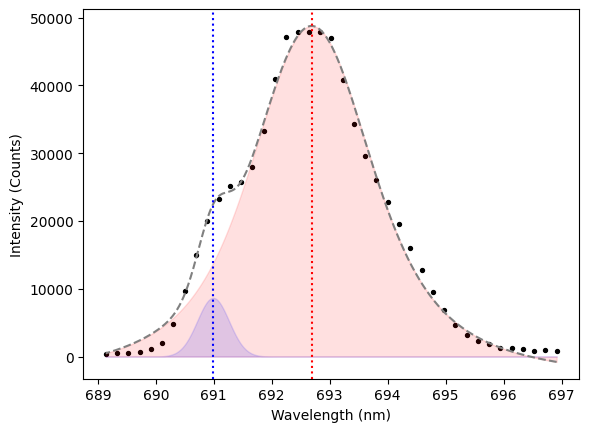

In [13]:
####
# 147
####
temp_index = 1

A1_guess_ocean = np.max(y_ocean_masked[temp_index]) / 2
A2_guess_ocean = 0.6 * A1_guess_ocean
R1_guess_ocean_147 = wavelengths_masked[temp_index][np.argmax(y_ocean_masked[temp_index])]
offset_guess_ocean_147 = np.min(y_ocean_masked[temp_index])

p0_ocean_147 = [A1_guess_ocean, R1_guess_ocean_147, 0.3, 0.3,
               A2_guess_ocean, -2, 0.3,0.3, offset_guess_ocean_147]

bounds_ocean_147 = [
    [0.01 * A1_guess_ocean, R1_guess_ocean_147 - 5, 0, 0,
     0.01 * A2_guess_ocean, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_ocean, R1_guess_ocean_147 + 5, np.inf, np.inf,
     10 * A2_guess_ocean, -1, np.inf, np.inf, np.inf]  #upper
]

pop_ocean_147, cov_ocean_147 = curve_fit(voigt_model_double,
                                       x_ocean_masked[temp_index],
                                       y_ocean_masked[temp_index],
                                       p0=p0_ocean_147,
                                       bounds=bounds_ocean_147,
                                       maxfev=10000)

x_fit_147 = np.linspace(x_ocean_masked[temp_index][-1], x_ocean_masked[temp_index][0], 10000)

pop_R1_ocean_147 = [pop_ocean_147[0], pop_ocean_147[1], pop_ocean_147[2], pop_ocean_147[3], pop_ocean_147[-1]]
R1_ocean_147 = voigt_profile_single(x_fit_147, *pop_R1_ocean_147)

pop_R2_ocean_147 = [pop_ocean_147[4], pop_ocean_147[5] + pop_ocean_147[1], pop_ocean_147[6], pop_ocean_147[7], 0]
R2_ocean_147 = voigt_profile_single(x_fit_147, *pop_R2_ocean_147)

cov_R1_ocean_147 = [cov_ocean_147[0][0], cov_ocean_147[1][1], cov_ocean_147[2][2], cov_ocean_147[3][3], cov_ocean_147[-1][-1]]
cov_R2_ocean_147 = [cov_ocean_147[4][4], cov_ocean_147[5][5] + cov_ocean_147[1][1], cov_ocean_147[6][6], cov_ocean_147[7][7], 0]

plt.figure(1)
plt.scatter(x_ocean_masked[temp_index], y_ocean_masked[temp_index], marker='o', color="black", s=8)
plt.plot(x_fit_147, voigt_model_double(x_fit_147, *pop_ocean_147), color="grey", linestyle="--")

plt.fill_between(x_fit_147, R1_ocean_147, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_147, R2_ocean_147, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_ocean_147[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_147[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

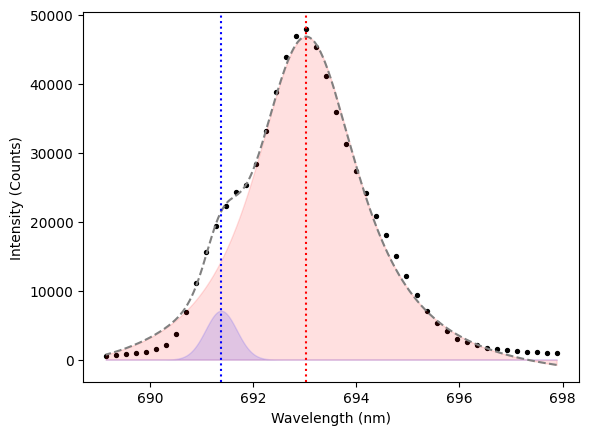

In [14]:
####
# 217
####
temp_index = 2

A1_guess_ocean = np.max(y_ocean_masked[temp_index]) / 2
A2_guess_ocean = 0.6 * A1_guess_ocean
R1_guess_ocean_217 = wavelengths_masked[temp_index][np.argmax(y_ocean_masked[temp_index])]
offset_guess_ocean_217 = np.min(y_ocean_masked[temp_index])

p0_ocean_217 = [A1_guess_ocean, R1_guess_ocean_217, 0.3, 0.3,
                A2_guess_ocean, -2, 0.3, 0.3, offset_guess_ocean_217]

bounds_ocean_217 = [
    [0.01 * A1_guess_ocean, R1_guess_ocean_217 - 5, 0, 0,
     0.01 * A2_guess_ocean, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_ocean, R1_guess_ocean_217 + 5, np.inf, np.inf,
     10 * A2_guess_ocean, -1, np.inf, np.inf, np.inf]  #upper
]

pop_ocean_217, cov_ocean_217 = curve_fit(voigt_model_double,
                                         x_ocean_masked[temp_index],
                                         y_ocean_masked[temp_index],
                                         p0=p0_ocean_217,
                                         bounds=bounds_ocean_217,
                                         maxfev=10000)

x_fit_217 = np.linspace(x_ocean_masked[temp_index][-1], x_ocean_masked[temp_index][0], 10000)

pop_R1_ocean_217 = [pop_ocean_217[0], pop_ocean_217[1], pop_ocean_217[2], pop_ocean_217[3], pop_ocean_217[-1]]
R1_ocean_217 = voigt_profile_single(x_fit_217, *pop_R1_ocean_217)

pop_R2_ocean_217 = [pop_ocean_217[4], pop_ocean_217[5] + pop_ocean_217[1], pop_ocean_217[6], pop_ocean_217[7], 0]
R2_ocean_217 = voigt_profile_single(x_fit_217, *pop_R2_ocean_217)

cov_R1_ocean_217 = [cov_ocean_217[0][0], cov_ocean_217[1][1], cov_ocean_217[2][2], cov_ocean_217[3][3], cov_ocean_217[-1][-1]]
cov_R2_ocean_217 = [cov_ocean_217[4][4], cov_ocean_217[5][5] + cov_ocean_217[1][1], cov_ocean_217[6][6], cov_ocean_217[7][7], 0]

plt.figure(1)
plt.scatter(x_ocean_masked[temp_index], y_ocean_masked[temp_index], marker='o', color="black", s=8)
plt.plot(x_fit_217, voigt_model_double(x_fit_217, *pop_ocean_217), color="grey", linestyle="--")

plt.fill_between(x_fit_217, R1_ocean_217, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_217, R2_ocean_217, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_ocean_217[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_217[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")
plt.show()

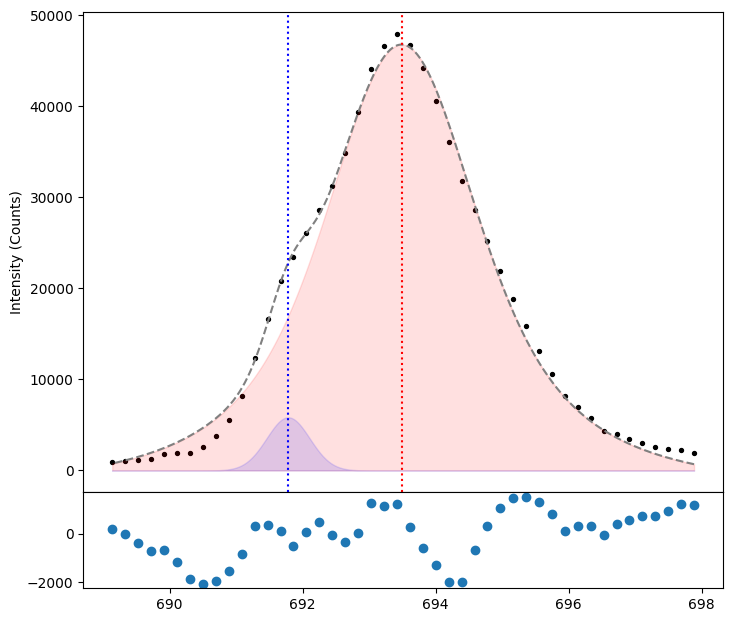

In [87]:
####
# 298
####
temp_index = 3

A1_guess_ocean = np.max(y_ocean_masked[temp_index]) / 2
A2_guess_ocean = 0.6 * A1_guess_ocean
R1_guess_ocean_298 = wavelengths_masked[temp_index][np.argmax(y_ocean_masked[temp_index])]
offset_guess_ocean_298 = np.min(y_ocean_masked[temp_index])

p0_ocean_298 = [A1_guess_ocean, R1_guess_ocean_298, 0.3, 0.3,
                A2_guess_ocean, -2, 0.3, 0.3, offset_guess_ocean_298]

bounds_ocean_298 = [
    [0.01 * A1_guess_ocean, R1_guess_ocean_298 - 5, 0, 0,
     0.01 * A2_guess_ocean, -3, 0, 0, -np.inf],  #lower
    [10 * A1_guess_ocean, R1_guess_ocean_298 + 5, np.inf, np.inf,
     10 * A2_guess_ocean, -1, np.inf, np.inf, np.inf]  #upper
]

pop_ocean_298, cov_ocean_298 = curve_fit(voigt_model_double,
                                         x_ocean_masked[temp_index],
                                         y_ocean_masked[temp_index],
                                         p0=p0_ocean_298,
                                         bounds=bounds_ocean_298,
                                         maxfev=10000)

x_fit_298 = np.linspace(x_ocean_masked[temp_index][-1], x_ocean_masked[temp_index][0], 10000)

pop_R1_ocean_298 = [pop_ocean_298[0], pop_ocean_298[1], pop_ocean_298[2], pop_ocean_298[3], pop_ocean_298[-1]]
R1_ocean_298 = voigt_profile_single(x_fit_298, *pop_R1_ocean_298)

pop_R2_ocean_298 = [pop_ocean_298[4], pop_ocean_298[5] + pop_ocean_298[1], pop_ocean_298[6], pop_ocean_298[7], 0]
R2_ocean_298 = voigt_profile_single(x_fit_298, *pop_R2_ocean_298)

cov_R1_ocean_298 = [cov_ocean_298[0][0], cov_ocean_298[1][1], cov_ocean_298[2][2], cov_ocean_298[3][3], cov_ocean_298[-1][-1]]
cov_R2_ocean_298 = [cov_ocean_298[4][4], cov_ocean_298[5][5] + cov_ocean_298[1][1], cov_ocean_298[6][6], cov_ocean_298[7][7], 0]

fig = plt.figure(1)
fig.add_axes([0,0,1,1])
plt.scatter(x_ocean_masked[temp_index], y_ocean_masked[temp_index], marker='o', color="black", s=8)
plt.plot(x_fit_298, voigt_model_double(x_fit_298, *pop_ocean_298), color="grey", linestyle="--")

plt.fill_between(x_fit_298, R1_ocean_298, 0, color="red", alpha=0.12)
plt.fill_between(x_fit_298, R2_ocean_298, 0, color="blue", alpha=0.12)

plt.axvline(pop_R1_ocean_298[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_298[1], color="blue", linestyle=":")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (Counts)")

fig.add_axes([0,-0.2,1,0.2])
plt.scatter(x_ocean_masked[temp_index],(y_ocean_masked[temp_index]-voigt_model_double(x_ocean_masked[temp_index], *pop_ocean_298)))
plt.show()

In [16]:
#functions for results table

def gaussian_FWHM(sigma):
    return 2*np.sqrt(2*np.log(2))*sigma

def voigt_FWHM(sigma, gamma):
    gamma_L = 2*gamma
    gamma_G = 2*np.sqrt(2*np.log(2))*sigma
    FWHM_V = 0.5346*gamma_L + np.sqrt(0.2166*gamma_L**2+gamma_G**2)
    return FWHM_V

# Key Results for results table

In [17]:
print(f"----- Mono 77 R1 -----")
print(f"R1: {pop_R1_mono_77[1]} ± {np.sqrt(cov_R1_mono_77[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_mono_77[2], sigma = pop_R1_mono_77[3])}")
print(f"FWHM_L:{2*pop_R1_mono_77[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_mono_77[3])}")

print(f"----- Mono 77 R2 -----")
print(f"R2: {pop_R2_mono_77[1]} ± {np.sqrt(cov_R2_mono_77[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_mono_77[2], sigma = pop_R2_mono_77[3])}")
print(f"FWHM_L:{2*pop_R2_mono_77[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_mono_77[3])}")

----- Mono 77 R1 -----
R1: 693.2769177727199 ± 11.99297084714881
FWHM_V:3.397580166224088
FWHM_L:0.13912602532012855
FWHM_G:3.3225725381399385
----- Mono 77 R2 -----
R2: 692.4526392681007 ± 32.56299669921466
FWHM_V:5.132476119752927
FWHM_L:3.7019265115204294
FWHM_G:2.6411653010443


In [18]:
print(f"----- Mono 147 R1 -----")
print(f"R1: {pop_R1_mono_147[1]} ± {np.sqrt(cov_R1_mono_147[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_mono_147[2], sigma = pop_R1_mono_147[3])}")
print(f"FWHM_L:{2*pop_R1_mono_147[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_mono_147[3])}")

print(f"----- Mono 147 R2 -----")
print(f"R2: {pop_R2_mono_147[1]} ± {np.sqrt(cov_R2_mono_147[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_mono_147[2], sigma = pop_R2_mono_147[3])}")
print(f"FWHM_L:{2*pop_R2_mono_147[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_mono_147[3])}")

----- Mono 147 R1 -----
R1: 693.3457342108638 ± 0.2106251328768503
FWHM_V:3.456240459406562
FWHM_L:1.8302593190484497
FWHM_G:2.3267649997888133
----- Mono 147 R2 -----
R2: 691.9849985776931 ± 0.24602889486338814
FWHM_V:2.4967905767111507
FWHM_L:2.496782956714536
FWHM_G:6.800963013340613e-05


In [19]:
print(f"----- Mono 217 R1 -----")
print(f"R1: {pop_R1_mono_217[1]} ± {np.sqrt(cov_R1_mono_217[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_mono_217[2], sigma = pop_R1_mono_217[3])}")
print(f"FWHM_L:{2*pop_R1_mono_217[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_mono_217[3])}")

print(f"----- Mono 217 R2 -----")
print(f"R2: {pop_R2_mono_217[1]} ± {np.sqrt(cov_R2_mono_217[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_mono_217[2], sigma = pop_R2_mono_217[3])}")
print(f"FWHM_L:{2*pop_R2_mono_217[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_mono_217[3])}")

----- Mono 217 R1 -----
R1: 693.6504920666786 ± 0.658460785704646
FWHM_V:3.9147001296886326
FWHM_L:8.843880405033373e-24
FWHM_G:3.9147001296886326
----- Mono 217 R2 -----
R2: 692.4723450741805 ± 1.1168744161095823
FWHM_V:3.233322636132078
FWHM_L:2.2738314570829483
FWHM_G:1.7179507431501428


In [20]:
print(f"----- Mono 298 R1 -----")
print(f"R1: {pop_R1_mono_298[1]} ± {np.sqrt(cov_R1_mono_298[1])}" )
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_mono_298[2], sigma = pop_R1_mono_298[3])}")
print(f"FWHM_L:{2*pop_R1_mono_298[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_mono_298[3])}")

print(f"----- Mono 298 R2 -----")
print(f"R2: {pop_R2_mono_298[1]} ± {np.sqrt(cov_R2_mono_298[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_mono_298[2], sigma = pop_R2_mono_298[3])}")
print(f"FWHM_L:{2*pop_R2_mono_298[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_mono_298[3])}")

----- Mono 298 R1 -----
R1: 694.2306720038582 ± 0.2797486631157982
FWHM_V:3.653737139342699
FWHM_L:1.1202576015005443
FWHM_G:3.010027367828432
----- Mono 298 R2 -----
R2: 692.7524224088463 ± 0.2867943180203724
FWHM_V:2.340167878379236
FWHM_L:2.533023000624257e-18
FWHM_G:2.340167878379236


In [21]:
print(f"----- Ocean 77 R1 -----")
print(f"R1: {pop_R1_ocean_77[1]} ± {np.sqrt(cov_R1_ocean_77[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_ocean_77[2], sigma = pop_R1_ocean_77[3])}")
print(f"FWHM_L:{2*pop_R1_ocean_77[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_ocean_77[3])}")

print(f"----- Ocean 77 R2 -----")
print(f"R2: {pop_R2_ocean_77[1]} ± {np.sqrt(cov_R2_ocean_77[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_ocean_77[2], sigma = pop_R2_ocean_77[3])}")
print(f"FWHM_L:{2*pop_R2_ocean_77[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_ocean_77[3])}")

----- Ocean 77 R1 -----
R1: 692.5576320534642 ± 0.02580503365789106
FWHM_V:2.241621319020144
FWHM_L:2.241614479565371
FWHM_G:7.462037461401318e-07
----- Ocean 77 R2 -----
R2: 690.8788440413293 ± 0.06509684207450193
FWHM_V:0.6144625473563405
FWHM_L:9.625189186313242e-39
FWHM_G:0.6144625473563405


In [22]:
print(f"----- Ocean 147 R1 -----")
print(f"R1: {pop_R1_ocean_147[1]} ± {np.sqrt(cov_R1_ocean_147[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_ocean_147[2], sigma = pop_R1_ocean_147[3])}")
print(f"FWHM_L:{2*pop_R1_ocean_147[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_ocean_147[3])}")

print(f"----- Ocean 147 R2 -----")
print(f"R2: {pop_R2_ocean_147[1]} ± {np.sqrt(cov_R2_ocean_147[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_ocean_147[2], sigma = pop_R2_ocean_147[3])}")
print(f"FWHM_L:{2*pop_R2_ocean_147[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_ocean_147[3])}")

----- Ocean 147 R1 -----
R1: 692.6879439159129 ± 0.029929762163610478
FWHM_V:2.5541195902461755
FWHM_L:1.7892352479378741
FWHM_G:1.3634121811480338
----- Ocean 147 R2 -----
R2: 690.9885547859942 ± 0.0567741327801078
FWHM_V:0.6450587834298012
FWHM_L:3.240939051534105e-36
FWHM_G:0.6450587834298012


In [23]:
print(f"----- Ocean 217 R1 -----")
print(f"R1: {pop_R1_ocean_217[1]} ± {np.sqrt(cov_R1_ocean_217[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_ocean_217[2], sigma = pop_R1_ocean_217[3])}")
print(f"FWHM_L:{2*pop_R1_ocean_217[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_ocean_217[3])}")

print(f"----- Ocean 217 R2 -----")
print(f"R2: {pop_R2_ocean_217[1]} ± {np.sqrt(cov_R2_ocean_217[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_ocean_217[2], sigma = pop_R2_ocean_217[3])}")
print(f"FWHM_L:{2*pop_R2_ocean_217[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_ocean_217[3])}")

----- Ocean 217 R1 -----
R1: 693.025207865668 ± 0.028387616446766913
FWHM_V:2.493862686555558
FWHM_L:2.2884902511443554
FWHM_G:0.6925548909788626
----- Ocean 217 R2 -----
R2: 691.3743894512797 ± 0.059455994474043976
FWHM_V:0.713587542416143
FWHM_L:1.3301857025489022e-33
FWHM_G:0.713587542416143


In [24]:
print(f"----- Ocean 298 R1 -----")
print(f"R1: {pop_R1_ocean_298[1]} ± {np.sqrt(cov_R1_ocean_298[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R1_ocean_298[2], sigma = pop_R1_ocean_298[3])}")
print(f"FWHM_L:{2*pop_R1_ocean_298[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R1_ocean_298[3])}")

print(f"----- Ocean 298 R2 -----")
print(f"R2: {pop_R2_ocean_298[1]} ± {np.sqrt(cov_R2_ocean_298[1])}")
print(f"FWHM_V:{voigt_FWHM(gamma = pop_R2_ocean_298[2], sigma = pop_R2_ocean_298[3])}")
print(f"FWHM_L:{2*pop_R2_ocean_298[2]}")
print(f"FWHM_G:{gaussian_FWHM(pop_R2_ocean_298[3])}")

----- Ocean 298 R1 -----
R1: 693.485808214483 ± 0.03308322977180124
FWHM_V:2.86054247437911
FWHM_L:2.091512528302222
FWHM_G:1.445173569641281
----- Ocean 298 R2 -----
R2: 691.7800701569084 ± 0.06635891937587597
FWHM_V:0.7616322680038156
FWHM_L:6.18365987362221e-37
FWHM_G:0.7616322680038156


# Ocean Optics Emission Spectra Plot Calculations

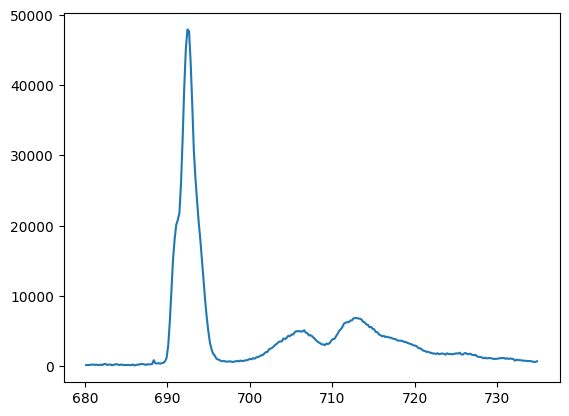

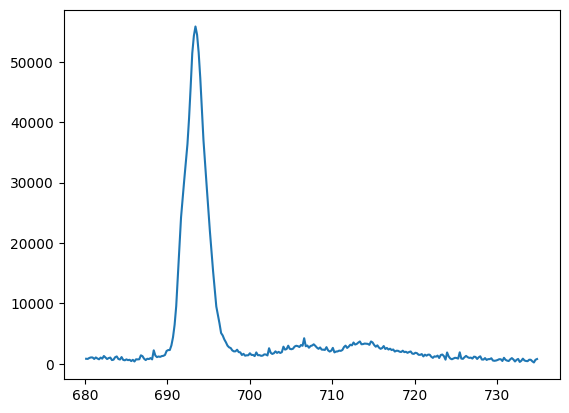

In [88]:
mask_77_broad = (x_ocean_77 >= 680) & (x_ocean_77 <= 735)
mask_298_broad = (x_ocean_298 >= 680) & (x_ocean_298 <= 735)
mask_298_fit = (x_ocean_298 >= 689.13) & (x_ocean_298 <= 697.89)

x_ocean_77, y_ocean_77 = np.array(x_ocean_77), np.array(y_ocean_77)

x_ocean_77_broad = x_ocean_77[mask_77_broad]
y_ocean_77_broad = y_ocean_77[mask_77_broad]

x_ocean_298_broad = x_ocean_298[mask_298_broad]
y_ocean_298_broad = y_ocean_298[mask_298_broad]
y_ocean_298_fit = y_ocean_298[mask_298_fit]


plt.figure(1)
plt.plot(x_ocean_77_broad, y_ocean_77_broad)
plt.show()

plt.figure(1)
plt.plot(x_ocean_298_broad, y_ocean_298_broad)
plt.show()

pop_ocean_298, cov_ocean_298 = curve_fit(voigt_model_double,
                                       x_ocean_masked[3],
                                       y_ocean_298_fit,
                                       p0 = p0_ocean_298,
                                         bounds = bounds_ocean_298,
                                         maxfev=10000)

# Plot

In [139]:
# Prep

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch

red_cb = "#e41a1c"
blue_cb = "#377eb8"

wavelength_range = np.linspace(x_ocean_77_broad[0], x_ocean_77_broad[-1], 1000)
marker_list = ["v","^"]
colour_list = [blue_cb, red_cb]
y_err = [np.max(y_ocean_masked[0])*0.01, np.max(y_ocean_masked[3])*0.01]
pop_list = [pop_ocean_77, pop_ocean_298]

residual_77 = (y_ocean_masked[0]-voigt_model_double(x_ocean_masked[0],*pop_ocean_77))/y_err[0]
residual_298 = (y_ocean_298_fit - voigt_model_double(x_ocean_masked[3], *pop_ocean_298))/y_err[1]

residual_list = [residual_77, residual_298]

residual_band_298 = Patch(
    facecolor=red_cb,
    alpha=0.12,
    label=r"$293\,\mathrm{K}\, 1\sigma$ Residuals"
)

residual_band_77 = Patch(
    facecolor=blue_cb,
    alpha=0.12,
    label=r"$77\,\mathrm{K}\, 1\sigma$ Residuals"
)

legend_elements = [
    Line2D([0], [0],
           color=red_cb,
           marker = marker_list[0],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,

           label=r"$298\,\mathrm{K}$"),

    residual_band_298,

    Line2D([0], [0],
           color=blue_cb,
           marker = marker_list[1],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"$77\,\mathrm{K}$"),

    residual_band_77
]

pc_savepath_ocean_emission_spectra = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\ocean_emission_spectra.png"
laptop_savepath_ocean_emission_spectra = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\ocean_emission_spectra.png"

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

# R1 and R2 positions
R1_293 = pop_ocean_298[1] + pop_ocean_298[5]
R2_293 = pop_ocean_298[1]

# R1 and R2 amplitudes
amp_R1_293 = voigt_model_double(np.array([R1_293]), *pop_ocean_298)[0]
amp_R2_293 = voigt_model_double(np.array([R2_293]), *pop_ocean_298)[0]

R1_77 = pop_ocean_77[1] + pop_ocean_77[5]
R2_77 = pop_ocean_77[1]

amp_R1_77 = voigt_model_double(np.array([R1_77]), *pop_ocean_77)[0]
amp_R2_77 = voigt_model_double(np.array([R2_77]), *pop_ocean_77)[0]

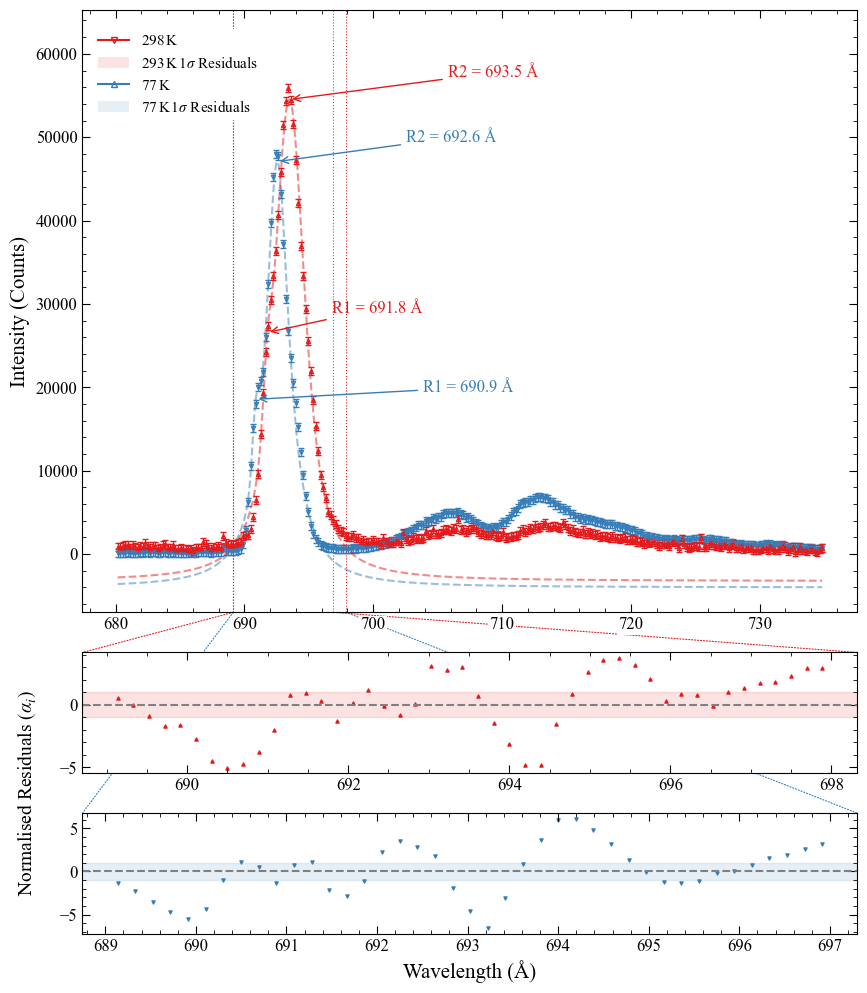

In [144]:
# Plot

fig = plt.figure(figsize = (10,12))

gs = fig.add_gridspec(
    5, 1,
    height_ratios=[6, 0.4, 1.2, 0.4, 1.2],  # spacer rows included
    hspace=0.0
)

ax_main = fig.add_subplot(gs[0])
ax_res_77 = fig.add_subplot(gs[4])
ax_res_298 = fig.add_subplot(gs[2])


##############
# Main Spectra
##############

for xdata, ydata, yerror, pop, marker, colour, xfit in zip(
    [x_ocean_77_broad, x_ocean_298_broad], [y_ocean_77_broad, y_ocean_298_broad], y_err, pop_list, marker_list, colour_list, [x_ocean_masked[0],x_ocean_masked[3]]
):
    ax_main.errorbar(xdata, ydata, yerr = yerror,
                     color = colour, marker = marker, linestyle = "none", markerfacecolor = "none", capsize = 2, markersize = 3, elinewidth=0.8)
    ax_main.plot(wavelength_range, voigt_model_double(wavelength_range, *pop),
                 color = colour, linestyle = "--", alpha = 0.5)

    ax_main.axvline(xfit[0], color = colour, linestyle = ":", linewidth = 0.8)
    ax_main.axvline(xfit[-1], color = colour, linestyle = ":", linewidth = 0.8)


# Get current limits
ymin, ymax = ax_main.get_ylim()

# Extend the top by, say, 10%
ax_main.set_ylim(ymin, ymax*1.1)

ax_main.set_ylabel("Intensity (Counts)")

ax_main.legend(
    handles = legend_elements,
    loc = "upper left",
    bbox_to_anchor = (0.005, 0.98),
    borderpad = 0.3,
    facecolor = "white",
    edgecolor = "white",
    framealpha = 1
)

##########################
# Main Spectra Annotations
##########################

# Annotate on ax_main
ax_main.annotate(
    rf"R1 = {R1_293:.1f} Å",
    xy=(R1_293, amp_R1_293),
    xytext=((R1_293+5), amp_R1_293*1.09),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_293:.1f} Å",
    xy=(R2_293, amp_R2_293),
    xytext=((R2_293+12.3), amp_R2_293*1.05),
    arrowprops=dict(arrowstyle="->", color=red_cb, lw=1),
    color=red_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R1 = {R1_77:.1f} Å",
    xy=(R1_77, amp_R1_77),
    xytext=((R1_77+13), amp_R1_77*1.05),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)

ax_main.annotate(
    rf"R2 = {R2_77:.1f} Å",
    xy=(R2_77, amp_R2_77),
    xytext=((R2_77+10), amp_R2_77*1.05),
    arrowprops=dict(arrowstyle="->", color=blue_cb, lw=1),
    color=blue_cb,
    fontsize=12
)


########
# insets
########
# a,b = 63,75
# ax_inset_293 = fig.add_axes([0.6,0.7,0.2,0.15])
# mark_inset(ax_main, ax_inset_293, loc1=2, loc2=4, fc="none", ec="black", lw = 0.5)
# ax_inset_293.errorbar(x_ocean_298_broad[a:b],y_ocean_298_broad[a:b], yerr = y_err[1],
#                    color=colour_list[1], capsize=2, fmt=marker_list[1], linestyle="none", markerfacecolor="none", markersize=3, elinewidth=0.8)
# ax_inset_293.plot(x_ocean_298_broad[a:b],voigt_model_double(x_ocean_298_broad[a:b],*pop_ocean_298),
#                color=colour_list[1], linestyle="-", alpha=0.5)
#
# c, d = 58, 70
# ax_inset_77 = fig.add_axes([0.6,0.49,0.2,0.15])
# mark_inset(ax_main, ax_inset_77, loc1=2, loc2=3, fc="none", ec="black", lw = 0.5)
# ax_inset_77.errorbar(x_ocean_77_broad[c:d],y_ocean_77_broad[c:d], yerr = y_err[0],
#                    color=colour_list[0], capsize=2, fmt=marker_list[0], linestyle="none", markerfacecolor="none", markersize=3, elinewidth=0.8)
# ax_inset_77.plot(x_ocean_77_broad[c:d],voigt_model_double(x_ocean_77_broad[c:d],*pop_ocean_77),
#                color=colour_list[0], linestyle="-", alpha=0.5)

###########
# Residuals
###########

for ax, xdata, residual, colour, marker in zip(
    [ax_res_77, ax_res_298], [x_ocean_masked[0], x_ocean_masked[3]], residual_list, colour_list, marker_list
):
    ax.scatter(xdata, residual,
               color = colour, marker = marker, s = 5)
    ax.axhspan(-1,1, color = colour, alpha = 0.12)
    ax.axhline(0, color = "grey", linestyle = "--")

# Get positions of residual axes
pos1 = ax_res_77.get_position()
pos2 = ax_res_298.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

# Shared residual label
fig.text(
    0.07, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)

ax_res_77.set_xlabel("Wavelength (Å)")

#########
# Styling
#########

for ax in [ax_main, ax_res_77, ax_res_298, ax_inset_77, ax_inset_293]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)
    for label in ax.get_xticklabels()+ ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

# Bottom of main axis in data coordinates
y_bottom = ax_main.get_ylim()[0]

# Example: connect left mask (293K) to top-left of residual 293 plot
con1 = ConnectionPatch(
    xyA=(x_ocean_masked[0][0], y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con1)

# Connect right mask (293K) to top-right of residual 293 plot
con2 = ConnectionPatch(
    xyA=(x_ocean_masked[0][-1], y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_298.transAxes,
    color=red_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con2)

# Same idea for 77K residuals
con3 = ConnectionPatch(
    xyA=(x_ocean_masked[3][0], y_bottom),
    coordsA=ax_main.transData,
    xyB=(0, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con3)

con4 = ConnectionPatch(
    xyA=(x_ocean_masked[3][-1], y_bottom),
    coordsA=ax_main.transData,
    xyB=(1, 1),
    coordsB=ax_res_77.transAxes,
    color=blue_cb,
    lw=0.8,
    linestyle=":",
    zorder=-1
)
fig.add_artist(con4)

plt.show()